In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score
import geopandas as gpd
from shapely.geometry import box

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
img_1985_path = "/content/drive/MyDrive/landsat_1985_june.tif"
img_2025_path = "/content/drive/MyDrive/landsat_2025_june.tif"

roi_1985_path = "/content/drive/MyDrive/1985_roi.shp"
roi_2025_path = "/content/drive/MyDrive/2025_roi.shp"

In [ ]:
src_1985 = rasterio.open(img_1985_path)
src_2025 = rasterio.open(img_2025_path)

img_1985 = src_1985.read()
img_2025 = src_2025.read()

img_2025 = img_2025[:6, :, :]

assert img_1985.shape[0] == img_2025.shape[0], (
    f"Band count mismatch: 1985={img_1985.shape[0]}, 2025={img_2025.shape[0]}"
)
print(f"1985 image shape: {img_1985.shape}")
print(f"2025 image shape: {img_2025.shape}")

# ── Z-score normalization (global per-band, across entire image) ──
def normalize_image(img):
    img_norm = np.zeros_like(img, dtype=np.float32)
    for b in range(img.shape[0]):
        band = img[b].astype(np.float32)
        std  = np.std(band)
        if std == 0:
            img_norm[b] = 0.0
        else:
            img_norm[b] = (band - np.mean(band)) / std
    return img_norm

img_1985_norm = normalize_image(img_1985)
img_2025_norm = normalize_image(img_2025)

print(f"\n1985 norm — min: {img_1985_norm.min():.4f}  max: {img_1985_norm.max():.4f}  mean: {img_1985_norm.mean():.4f}")
print(f"2025 norm — min: {img_2025_norm.min():.4f}  max: {img_2025_norm.max():.4f}  mean: {img_2025_norm.mean():.4f}")

# ── Load and reproject ROIs to match raster CRS ──
roi_1985 = gpd.read_file(roi_1985_path).to_crs(src_1985.crs)
roi_2025 = gpd.read_file(roi_2025_path).to_crs(src_2025.crs)

print(f"\n1985 ROI classes: {sorted(roi_1985['Classvalue'].unique())}")
print(f"2025 ROI classes: {sorted(roi_2025['Classvalue'].unique())}")
print(f"roi_1985 CRS: {roi_1985.crs}")
print(f"roi_2025 CRS: {roi_2025.crs}")

1985 image shape: (6, 964, 2058)
2025 image shape: (6, 964, 2058)

1985 norm — min: -2.2870  max: 36.7710  mean: 0.0000
2025 norm — min: -8.8457  max: 13.4982  mean: 0.0000

1985 ROI classes: [np.int64(0), np.int64(1)]
2025 ROI classes: [np.int64(0), np.int64(1)]
roi_1985 CRS: PROJCS["NAD83 / UTM zone 12N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26912"]]
roi_2025 CRS: PROJCS["NAD83 / UTM zone 12N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.25

In [ ]:
def extract_training_pixels(src, img_norm, roi_gdf, max_per_roi=20000, balanced_n=5000):
    """
    Uses the raw src ONLY to build the valid-pixel mask per polygon.
    All feature values come from img_norm (globally z-score normalized).
    """
    X_list, y_list = [], []

    dtype    = src.dtypes[0]
    fill_val = 0 if np.dtype(dtype).kind == 'u' else -9999
    print(f"  Raster dtype: {dtype}  →  fill_value={fill_val}")

    for _, row in roi_gdf.iterrows():
        geom  = [row.geometry]
        label = row["Classvalue"]

        try:
            out_img, out_transform = mask(src, geom, crop=True,
                                          nodata=fill_val, all_touched=True)
        except Exception as e:
            print(f"  Skipping class {label} — mask failed: {e}")
            continue

        # Valid-pixel boolean mask from the raw crop
        valid_mask = out_img[0] != fill_val

        if not valid_mask.any():
            print(f"  Warning: no valid pixels for class {label}, skipping.")
            continue

        # ── Locate this crop window inside the full raster ──
        row_off, col_off = src.index(out_transform.c, out_transform.f)
        crop_h, crop_w   = out_img.shape[1], out_img.shape[2]

        row_off = max(0, row_off)
        col_off = max(0, col_off)
        row_end = min(row_off + crop_h, img_norm.shape[1])
        col_end = min(col_off + crop_w,  img_norm.shape[2])

        # Slice globally normalized image to the same window
        norm_crop  = img_norm[:, row_off:row_end, col_off:col_end]

        # Trim mask if edge-clamping made the crop smaller
        valid_mask = valid_mask[:norm_crop.shape[1], :norm_crop.shape[2]]

        if not valid_mask.any():
            continue

        # ── Extract features from the NORMALIZED image ──
        X = norm_crop[:, valid_mask].T.astype(np.float32)

        if X.shape[0] == 0:
            continue

        # Cap per ROI
        if X.shape[0] > max_per_roi:
            idx = np.random.choice(X.shape[0], max_per_roi, replace=False)
            X   = X[idx]

        y = np.full(X.shape[0], label, dtype=np.int32)
        X_list.append(X)
        y_list.append(y)

    if not X_list:
        raise RuntimeError("No training pixels extracted — check ROI file and CRS.")

    X_all = np.vstack(X_list)
    y_all = np.concatenate(y_list)

    print(f"\n  Raw pixel counts per class:")
    for cls in np.unique(y_all):
        print(f"    Class {cls}: {(y_all == cls).sum()} pixels")

    # ── Balance classes ──
    X_bal, y_bal = [], []
    for cls in np.unique(y_all):
        X_cls   = X_all[y_all == cls]
        n       = len(X_cls)
        replace = n < balanced_n
        idx     = np.random.choice(n, balanced_n, replace=replace)
        X_bal.append(X_cls[idx])
        y_bal.append(np.full(balanced_n, cls, dtype=np.int32))

    return np.vstack(X_bal), np.concatenate(y_bal)


# img_norm is passed in — features come from z-score normalized arrays
print("\nExtracting 1985 training pixels...")
X_1985, y_1985 = extract_training_pixels(src_1985, img_1985_norm, roi_1985)

print("\nExtracting 2025 training pixels...")
X_2025, y_2025 = extract_training_pixels(src_2025, img_2025_norm, roi_2025)


Extracting 1985 training pixels...
  Raster dtype: uint16  →  fill_value=0

  Raw pixel counts per class:
    Class 0: 258911 pixels
    Class 1: 105200 pixels

Extracting 2025 training pixels...
  Raster dtype: uint16  →  fill_value=0

  Raw pixel counts per class:
    Class 0: 180135 pixels
    Class 1: 44553 pixels


In [ ]:
X_all = np.vstack([X_1985, X_2025])
y_all = np.concatenate([y_1985, y_2025])

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

print("\nTraining SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train, y_train)
print("Done.")

y_pred = svm.predict(X_test)

cm    = confusion_matrix(y_test, y_pred)
oa    = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
aa    = np.mean(np.diag(cm) / cm.sum(axis=1))

print("\n" + "="*50)
print("ACCURACY METRICS (held-out test set)")
print("="*50)
print(f"Overall Accuracy (OA) : {oa:.4f}")
print(f"Average Accuracy (AA) : {aa:.4f}")
print(f"Kappa                 : {kappa:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nPer-class report:")
print(classification_report(y_test, y_pred))

Train: 16000  |  Test: 4000

Training SVM...
Done.

ACCURACY METRICS (held-out test set)
Overall Accuracy (OA) : 0.9998
Average Accuracy (AA) : 0.9998
Kappa                 : 0.9995

Confusion Matrix:
 [[1999    1]
 [   0 2000]]

Per-class report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [ ]:
def classify_in_tiles_svm(img_norm, model, tile_size=256):
    bands, rows, cols = img_norm.shape
    out = np.zeros((rows, cols), dtype=np.uint8)

    total_tiles = ((rows // tile_size) + 1) * ((cols // tile_size) + 1)
    tile_count  = 0

    for r in range(0, rows, tile_size):
        for c in range(0, cols, tile_size):
            r_end = min(r + tile_size, rows)
            c_end = min(c + tile_size, cols)

            tile = img_norm[:, r:r_end, c:c_end]
            X    = tile.reshape(bands, -1).T.astype(np.float32)

            preds = model.predict(X)
            out[r:r_end, c:c_end] = preds.reshape(r_end - r, c_end - c)

            tile_count += 1
            if tile_count % 20 == 0:
                print(f"  Processed {tile_count}/{total_tiles} tiles...")

    return out


print("Classifying 1985 image...")
classified_1985 = classify_in_tiles_svm(img_1985_norm, svm)
print("Done.\n")

print("Classifying 2025 image...")
classified_2025 = classify_in_tiles_svm(img_2025_norm, svm)
print("Done.")

# Pixel count summary
for year, classified in [("1985", classified_1985), ("2025", classified_2025)]:
    print(f"\n{year} class distribution:")
    for cls in np.unique(classified):
        pct = (classified == cls).sum() / classified.size * 100
        print(f"  Class {cls}: {pct:.2f}%")

Classifying 1985 image...
  Processed 20/36 tiles...
Done.

Classifying 2025 image...
  Processed 20/36 tiles...
Done.

1985 class distribution:
  Class 0: 84.01%
  Class 1: 15.99%

2025 class distribution:
  Class 0: 91.33%
  Class 1: 8.67%


In [ ]:
# Classify both images
print("Classifying 1985...")
pred_1985_raster = classify_in_tiles_svm(img_1985_norm, svm, tile_size=256)
print("Done.\n")


Classifying 1985...
  Processed 20/36 tiles...
Done.



In [ ]:
print("Classifying 2025...")
pred_2025_raster = classify_in_tiles_svm(img_2025_norm, svm, tile_size=256)
print("Done.\n")


Classifying 2025...
  Processed 20/36 tiles...
Done.



In [ ]:
def save_classification(classified, src, output_path):
    profile = src.profile.copy()
    profile.update(count=1, dtype='uint8', nodata=255)

    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(classified.astype('uint8'), 1)
    print(f"Saved: {output_path}")


save_classification(pred_1985_raster, src_1985,
                    "/content/drive/MyDrive/classified_1985.tif")

save_classification(pred_2025_raster, src_2025,
                    "/content/drive/MyDrive/classified_2025.tif")

Saved: /content/drive/MyDrive/classified_1985.tif
Saved: /content/drive/MyDrive/classified_2025.tif


In [ ]:
for year, classified in [("1985", pred_1985_raster), ("2025", pred_2025_raster)]:
    print(f"\n{year} class distribution:")
    for cls in np.unique(classified):
        pct = (classified == cls).sum() / classified.size * 100
        print(f"  Class {cls}: {pct:.2f}%")


1985 class distribution:
  Class 0: 84.01%
  Class 1: 15.99%

2025 class distribution:
  Class 0: 91.33%
  Class 1: 8.67%


Detection Change

In [ ]:
from rasterio.transform import from_bounds

In [ ]:
# ── CHANGE DETECTION: Water Loss 1985 → 2025 ──────────────────────────────────
# Define your water class value (adjust if different in your ROI)
WATER_CLASS = 1  # <-- change this to match your water Classvalue

def calculate_water_change(classified_1985, classified_2025, src_1985, src_2025, water_class=WATER_CLASS):
    """
    Compares two classified rasters and calculates water area change in km².
    Assumes both rasters share the same grid (same CRS, extent, resolution).
    If resolutions differ, the 2025 result is resampled to match 1985.
    """

    # ── Pixel area in km² ──────────────────────────────────────────────────────
    # rasterio transform res() returns (x_res, y_res) in CRS units
    # For UTM/projected CRS: units are meters → divide by 1e6 for km²
    # For geographic CRS (degrees): approximate using ~111km/degree at equator
    transform = src_1985.transform
    x_res = abs(transform.a)
    y_res = abs(transform.e)

    crs = src_1985.crs
    if crs.is_geographic:
        # Convert degrees to meters (approximate)
        center_lat = (src_1985.bounds.top + src_1985.bounds.bottom) / 2
        x_m = x_res * 111320 * np.cos(np.radians(center_lat))
        y_m = y_res * 111320
        pixel_area_km2 = (x_m * y_m) / 1e6
        print(f"Geographic CRS detected — approximate pixel area: {pixel_area_km2:.6f} km²")
    else:
        pixel_area_km2 = (x_res * y_res) / 1e6
        print(f"Projected CRS detected — pixel area: {pixel_area_km2:.6f} km²")

    # ── Align grids if shapes differ ───────────────────────────────────────────
    if classified_1985.shape != classified_2025.shape:
        print(f"Shape mismatch: 1985={classified_1985.shape}, 2025={classified_2025.shape}")
        print("Cropping 2025 to match 1985 extent...")
        min_rows = min(classified_1985.shape[0], classified_2025.shape[0])
        min_cols = min(classified_1985.shape[1], classified_2025.shape[1])
        classified_1985 = classified_1985[:min_rows, :min_cols]
        classified_2025 = classified_2025[:min_rows, :min_cols]

    # ── Binary water masks ─────────────────────────────────────────────────────
    water_1985 = (classified_1985 == water_class)
    water_2025 = (classified_2025 == water_class)

    # ── Change categories ──────────────────────────────────────────────────────
    water_lost     = water_1985 & ~water_2025   # was water, now isn't
    water_gained   = ~water_1985 & water_2025   # wasn't water, now is
    water_stable   = water_1985 & water_2025    # water in both years
    nonwater_both  = ~water_1985 & ~water_2025  # non-water in both

    # ── Area calculations ──────────────────────────────────────────────────────
    area_1985_km2    = water_1985.sum()   * pixel_area_km2
    area_2025_km2    = water_2025.sum()   * pixel_area_km2
    area_lost_km2    = water_lost.sum()   * pixel_area_km2
    area_gained_km2  = water_gained.sum() * pixel_area_km2
    area_stable_km2  = water_stable.sum() * pixel_area_km2
    net_change_km2   = area_2025_km2 - area_1985_km2
    pct_change       = (net_change_km2 / area_1985_km2 * 100) if area_1985_km2 > 0 else 0

    # ── Report ─────────────────────────────────────────────────────────────────
    print("\n" + "=" * 55)
    print("  WATER CHANGE DETECTION — Lake Powell 1985 → 2025")
    print("=" * 55)
    print(f"  Water area in 1985        : {area_1985_km2:>10.2f} km²")
    print(f"  Water area in 2025        : {area_2025_km2:>10.2f} km²")
    print(f"  ── ── ── ── ── ── ── ── ──")
    print(f"  Stable water (both years) : {area_stable_km2:>10.2f} km²")
    print(f"  Water LOST  (1985→2025)   : {area_lost_km2:>10.2f} km²  ⬇")
    print(f"  Water GAINED (new water)  : {area_gained_km2:>10.2f} km²  ⬆")
    print(f"  ── ── ── ── ── ── ── ── ──")
    print(f"  Net change                : {net_change_km2:>+10.2f} km²")
    print(f"  % change from 1985 base   : {pct_change:>+10.2f}%")
    print("=" * 55)

    return {
        "water_lost_mask":    water_lost,
        "water_gained_mask":  water_gained,
        "water_stable_mask":  water_stable,
        "area_1985_km2":      area_1985_km2,
        "area_2025_km2":      area_2025_km2,
        "area_lost_km2":      area_lost_km2,
        "area_gained_km2":    area_gained_km2,
        "area_stable_km2":    area_stable_km2,
        "net_change_km2":     net_change_km2,
        "pct_change":         pct_change,
        "pixel_area_km2":     pixel_area_km2,
    }


results = calculate_water_change(pred_1985_raster, pred_2025_raster, src_1985, src_2025)

Projected CRS detected — pixel area: 0.000900 km²

  WATER CHANGE DETECTION — Lake Powell 1985 → 2025
  Water area in 1985        :     285.55 km²
  Water area in 2025        :     154.89 km²
  ── ── ── ── ── ── ── ── ──
  Stable water (both years) :     150.34 km²
  Water LOST  (1985→2025)   :     135.21 km²  ⬇
  Water GAINED (new water)  :       4.55 km²  ⬆
  ── ── ── ── ── ── ── ── ──
  Net change                :    -130.66 km²
  % change from 1985 base   :     -45.76%


In [ ]:
# Encoding: 0=non-water both | 1=stable water | 2=water lost | 3=water gained
change_map = np.zeros_like(pred_1985_raster, dtype=np.uint8)
change_map[results["water_stable_mask"]] = 1
change_map[results["water_lost_mask"]]   = 2
change_map[results["water_gained_mask"]] = 3

def save_change_map(change_map, src, output_path):
    profile = src.profile.copy()
    profile.update(count=1, dtype='uint8', nodata=255)
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(change_map.astype('uint8'), 1)
    print(f"Change map saved: {output_path}")
    print("  Legend → 0: non-water (both) | 1: stable water | 2: water LOST | 3: water GAINED")

save_change_map(change_map, src_1985, "/content/drive/MyDrive/water_change_1985_2025.tif")


Change map saved: /content/drive/MyDrive/water_change_1985_2025.tif
  Legend → 0: non-water (both) | 1: stable water | 2: water LOST | 3: water GAINED


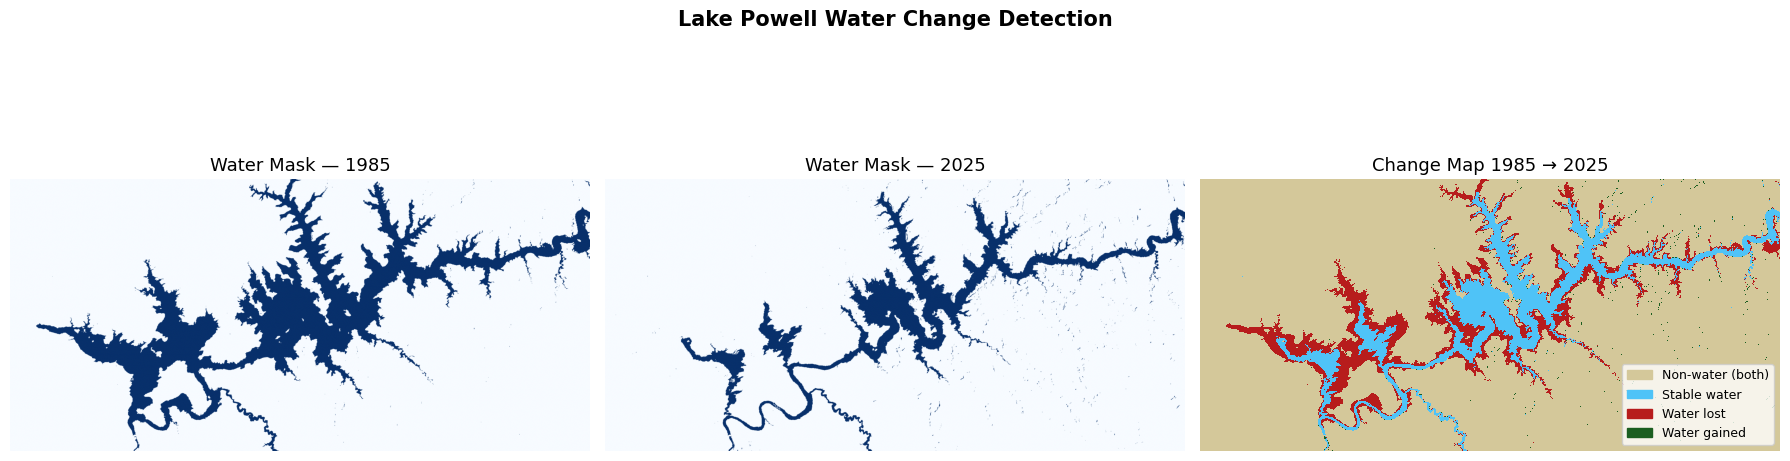

Figure saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

cmap   = ListedColormap(["#d4c89a", "#4fc3f7", "#b71c1c", "#1b5e20"])
labels = ["Non-water (both)", "Stable water", "Water lost", "Water gained"]
patches = [mpatches.Patch(color=c, label=l) for c, l in
           zip(["#d4c89a", "#4fc3f7", "#b71c1c", "#1b5e20"], labels)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(pred_1985_raster == WATER_CLASS, cmap="Blues")
axes[0].set_title("Water Mask — 1985", fontsize=13)

axes[1].imshow(pred_2025_raster == WATER_CLASS, cmap="Blues")
axes[1].set_title("Water Mask — 2025", fontsize=13)

axes[2].imshow(change_map, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
axes[2].set_title("Change Map 1985 → 2025", fontsize=13)
axes[2].legend(handles=patches, loc="lower right", fontsize=9)

for ax in axes:
    ax.axis("off")

plt.suptitle("Lake Powell Water Change Detection", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/water_change_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

In [ ]:
html_content = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Lake Powell — Water Change Detection</title>
  <script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>
  <style>
    /* paste the CSS from the widget here */
  </style>
</head>
<body>
  <!-- paste the HTML from the widget here -->
</body>
</html>"""

output_path = "/content/drive/MyDrive/lake_powell_change_report.html"
with open(output_path, "w") as f:
    f.write(html_content)
print(f"Report saved to {output_path}")

Report saved to /content/drive/MyDrive/lake_powell_change_report.html
